In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f8
function_folder = os.path.join(base_dir, "function_8")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f8 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 8: shape = {df_f8.shape}, columns = {df_f8.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
week1_results = {"f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581)}

In [4]:
week2_results = {"f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961)}

In [5]:
week3_results = {"f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661)}

In [6]:
week5_results = {"f8": ([0.325520, 0.209525, 0.057274, 0.198246, 0.813824, 0.387519, 0.169663, 0.663670], 9.861549762954)}

In [7]:
week6_results = {"f8": ([0.924338, 0.001471, 0.948665, 0.928797, 0.142329, 0.071686, 0.034416, 0.347751], 5.5407934131584)}

In [8]:
week7_results = {"f8": ([0.088856, 0.892449, 0.024530, 0.962260, 0.982699, 0.389537, 0.966989, 0.307254], 7.5413772236639005)}

In [9]:
week8_results = {"f8": ([0.041050, 0.781948, 0.001813, 0.992673, 0.545189, 0.662834, 0.042235, 0.825023], 8.7204756545406)}

In [10]:
week9_results = {"f8": ([0.241028, 0.000000, 0.149637, 0.000000, 1.000000, 0.187244, 0.264684, 1.000000], 9.771881015877)}

In [11]:
week10_results = {"f8": ([0.190066, 0.209525, 0.197386, 0.198246, 0.813824, 0.387519, 0.125488, 0.663670], 9.940025720132)}

In [12]:
week11_results = {"f8": ([0.187264, 0.209525, 0.213429, 0.198246, 0.813824, 0.387519, 0.169612, 0.663670], 9.943018117517)}

In [13]:
week12_results = {"f8": ([0.342633, 0.209525, 0.089809, 0.198246, 0.813824, 0.387519, 0.130948, 0.663670], 9.848852331891)}

In [14]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
    "week12": week12_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f8

for week, results in weekly_results.items():
    
    if "f8" not in results:
        continue
    
    inputs, output = results["f8"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f8
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8", "y1"]
    )
    
    # append to df_f8
    df_f8 = pd.concat([df_f8, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f8 = df_f8.drop_duplicates(ignore_index=True)

print("updated f8 shape:", df_f8.shape)


updated f8 shape: (51, 9)


In [15]:
print(df_f8)

          X1        X2        X3        X4        X5        X6        X7  \
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347   
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068   
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907   
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380   
9   0.984933  0.699506  0.998885  0.180148  0.580143  0.231087  0.490827   
10  0.112071  0.437736  0.596599  0.592776  0.226982  0.410105  0.921238   
11  0.791888  0.576191  0.694528  0.283424  0.136755  0.279162  0.842767   
12  0.143550

In [16]:
display(df_f8.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,51.0,0.480807,0.311222,0.009077,0.190417,0.447096,0.778582,0.985945
X2,51.0,0.446084,0.319412,0.000000,0.191912,0.458759,0.725326,0.973980
X3,51.0,0.450185,0.303858,0.001813,0.216457,0.376751,0.724607,0.998885
X4,51.0,0.421712,0.286710,0.000000,0.189197,0.387609,0.665360,0.992673
X5,51.0,0.519176,0.290541,0.009649,0.256311,0.545189,0.768303,1.000000
X6,51.0,0.447772,0.258631,0.022113,0.248903,0.387519,0.658701,0.990244
X7,51.0,0.513951,0.291347,0.034416,0.234277,0.553779,0.759155,0.992914
X8,51.0,0.529799,0.268454,0.041956,0.330717,0.560918,0.722286,1.000000
y1,51.0,8.078588,1.171475,5.540793,7.319164,8.042213,8.903650,9.948689


## Feature vs y scatter plots


Feature vs y1 for f8


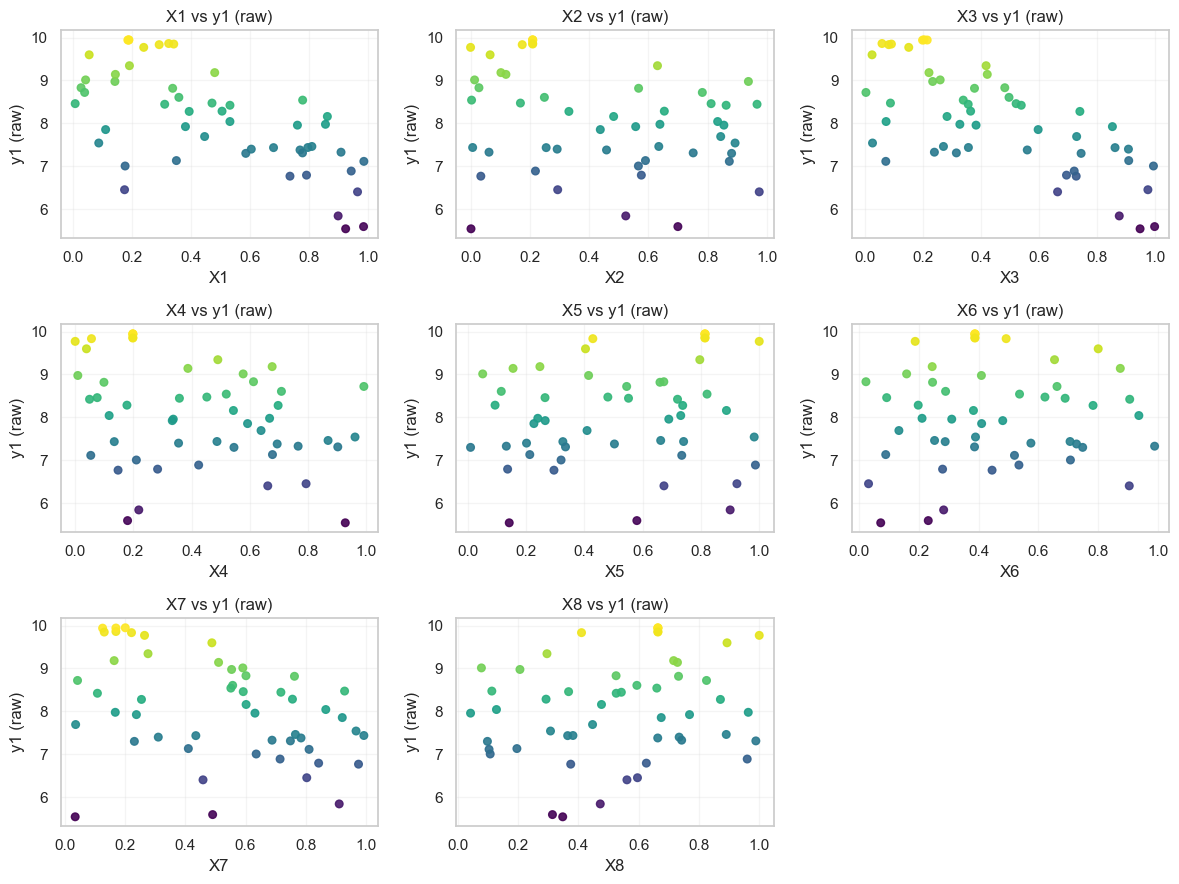

In [17]:
print("\nFeature vs y1 for f8")

# extract inputs and output for f8
input_cols_f8 = [c for c in df_f8.columns if c.startswith("X")]
X_f8 = df_f8[input_cols_f8].values
y_f8 = df_f8["y1"].values

# number of input features
n_features = X_f8.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# flatten axes safely
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f8):
    ax = axes[j]
    sc = ax.scatter(
        X_f8[:, j],
        y_f8,
        c=y_f8,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## 1D Marginal GP Posterior Probes


fitted gp_f8 kernel:
0.716**2 * Matern(length_scale=[0.2, 1.72, 0.2, 1.49, 2.35, 25, 0.711, 25], nu=2.5) + WhiteKernel(noise_level=1e-08)
log marginal likelihood: -29.726567788276046

fitted ard length scales for f8:
  X1: 0.2000
  X2: 1.7214
  X3: 0.2000
  X4: 1.4858
  X5: 2.3549
  X6: 25.0000
  X7: 0.7113
  X8: 25.0000


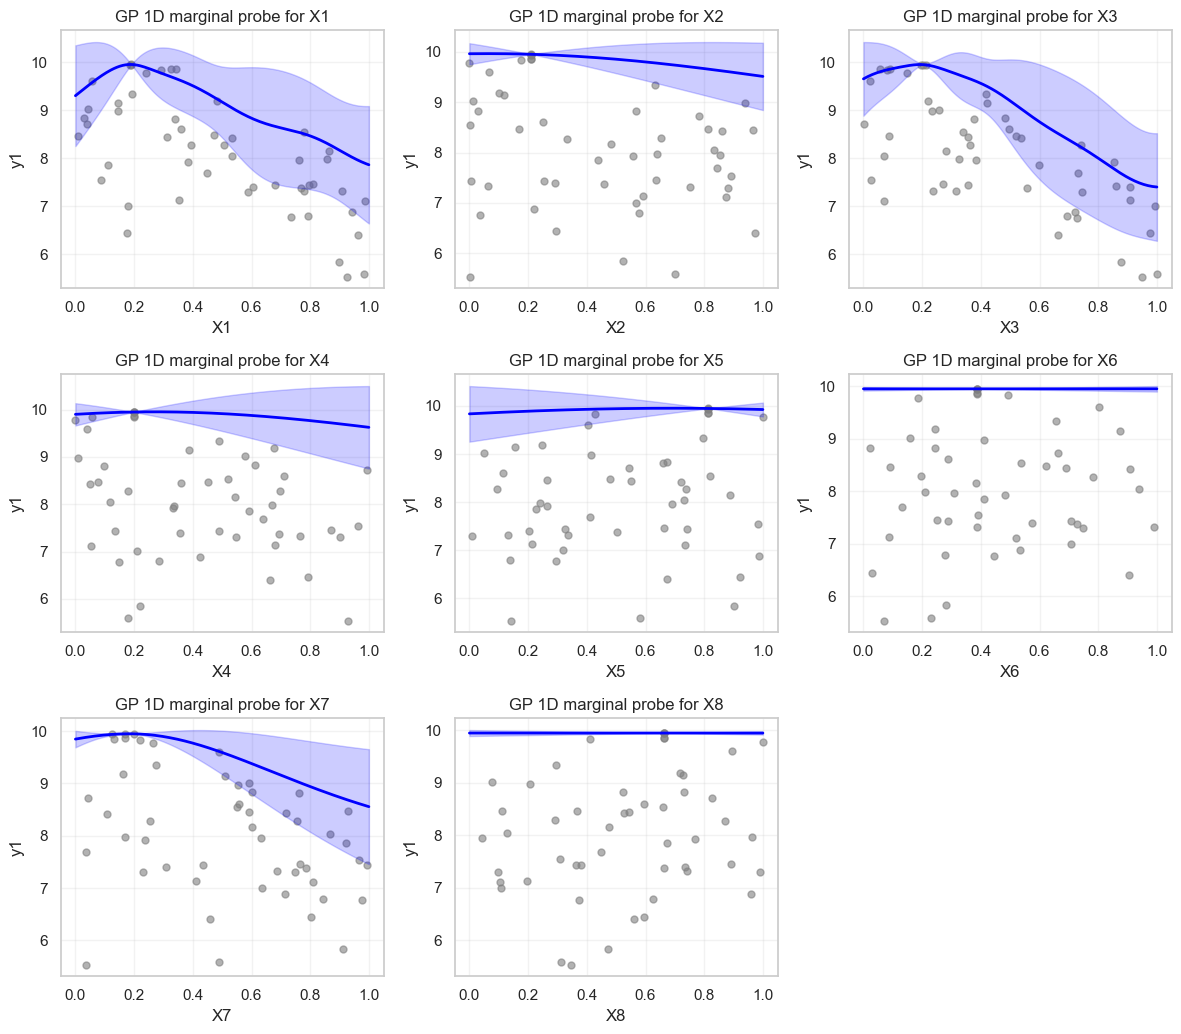

In [18]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

# build and fit gp_f8 on df_f8

input_cols_f8 = [c for c in df_f8.columns if c.startswith("X")]
X_f8 = df_f8[input_cols_f8].values.astype(float)
y_f8 = df_f8["y1"].values.astype(float)

# optional: scale y for numerical stability
y_scaler_f8 = StandardScaler()
y_f8_scaled = y_scaler_f8.fit_transform(y_f8.reshape(-1, 1)).ravel()

n_dims = X_f8.shape[1]

ls_lower = np.array([0.02, 0.50, 0.02, 0.30, 0.50, 5.0, 0.05, 5.0])
ls_upper = np.array([0.20, 5.0, 0.20, 5.0, 8.0, 25.0, 0.80, 25.0])
ls_bounds = list(zip(ls_lower, ls_upper))

kernel_f8 = (
    C(1.0, (1e-3, 10.0))
    * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=ls_bounds,
        nu=2.5
    )
    + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 0.5))
)

gp_f8 = GPR(
    kernel=kernel_f8,
    alpha=1e-6,
    n_restarts_optimizer=29,
    normalize_y=False,
    random_state=42
)

gp_f8.fit(X_f8, y_f8_scaled)

print("\nfitted gp_f8 kernel:")
print(gp_f8.kernel_)
print("log marginal likelihood:", gp_f8.log_marginal_likelihood_value_)

try:
    ls_fitted = gp_f8.kernel_.k1.k2.length_scale
    dim_names = input_cols_f8
    print("\nfitted ard length scales for f8:")
    for name, ls_val in zip(dim_names, ls_fitted):
        print(f"  {name}: {ls_val:.4f}")
except AttributeError:
    print("inspect gp_f8.kernel_ manually")


def gp_1d_marginals_df8(df_f8, gp_model, y_scaler, n_points=200):
    input_cols = [c for c in df_f8.columns if c.startswith("X")]
    X = df_f8[input_cols].values.astype(float)
    y = df_f8["y1"].values.astype(float)

    best_idx = np.argmax(y)
    x_best = X[best_idx].copy()

    d = X.shape[1]
    ncols = 3
    nrows = int(np.ceil(d / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))

    if nrows * ncols == 1:
        axes = [axes]
    else:
        axes = axes.ravel().tolist()

    for j, col in enumerate(input_cols):
        ax = axes[j]

        xi = np.linspace(0.0, 1.0, n_points)
        X_probe = np.tile(x_best, (n_points, 1))
        X_probe[:, j] = xi

        mu_scaled, std_scaled = gp_model.predict(X_probe, return_std=True)
        mu = y_scaler.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
        std = std_scaled * y_scaler.scale_[0]

        ax.scatter(X[:, j], y, c="gray", s=25, alpha=0.6, label="observed")
        ax.plot(xi, mu, color="blue", linewidth=2, label="GP mean")
        ax.fill_between(xi, mu - 2 * std, mu + 2 * std,
                        color="blue", alpha=0.2, label="±2σ")

        ax.set_xlabel(col)
        ax.set_ylabel("y1")
        ax.set_title(f"GP 1D marginal probe for {col}")
        ax.grid(alpha=0.25)

    for k in range(d, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()


gp_1d_marginals_df8(df_f8, gp_f8, y_scaler_f8)


## Distribution Analysis

f8 – feature and output distributions


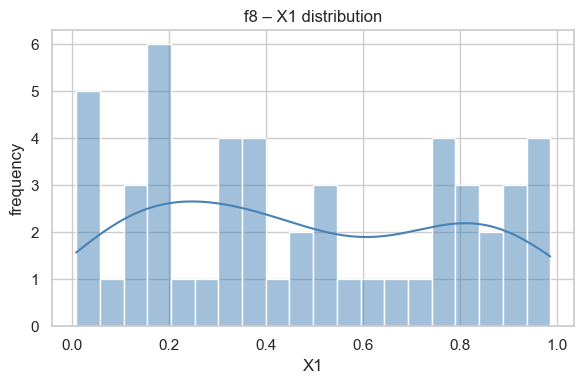

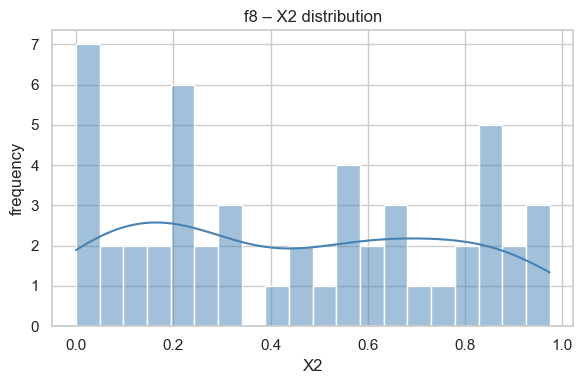

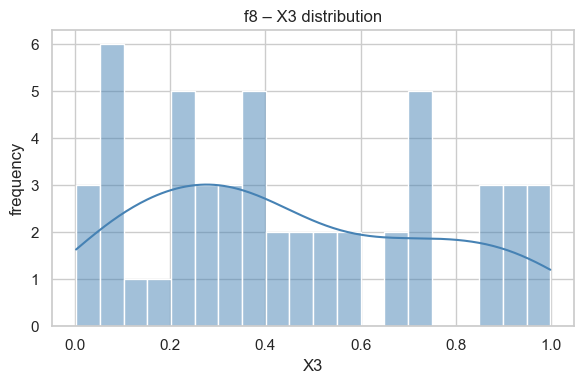

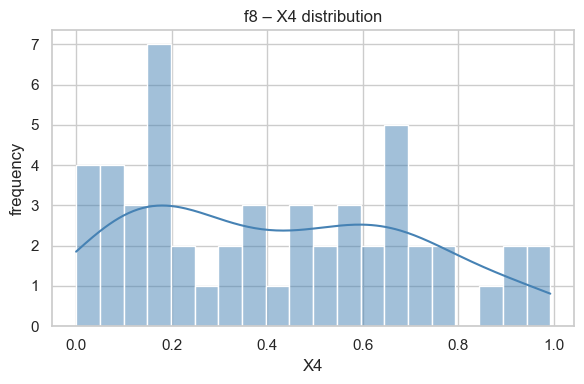

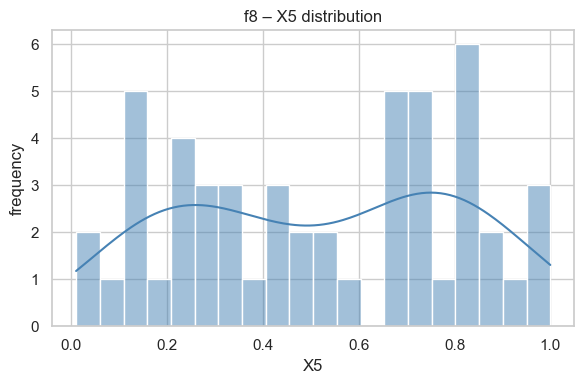

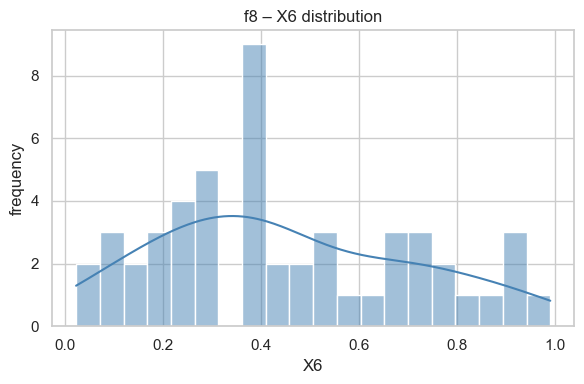

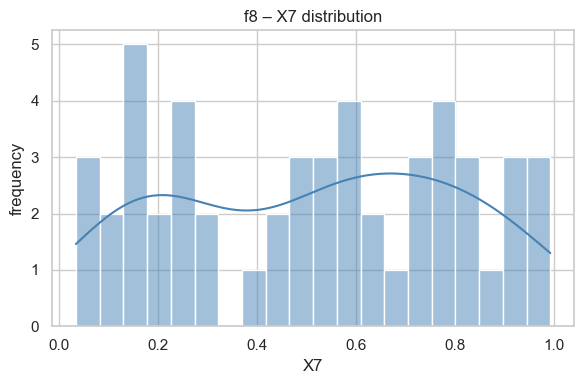

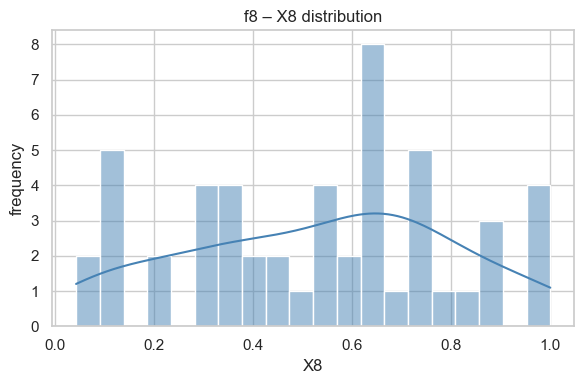

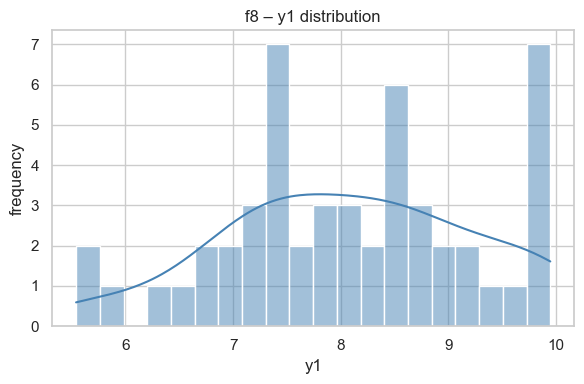

In [19]:
input_cols_f8 = [c for c in df_f8.columns if c.startswith("X")]
output_col_f8 = [c for c in df_f8.columns if c.startswith("y")][0]

print("f8 – feature and output distributions")

all_cols_raw_f8 = input_cols_f8 + [output_col_f8]

for col in all_cols_raw_f8:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f8[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f8 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f8 – y vs instance index


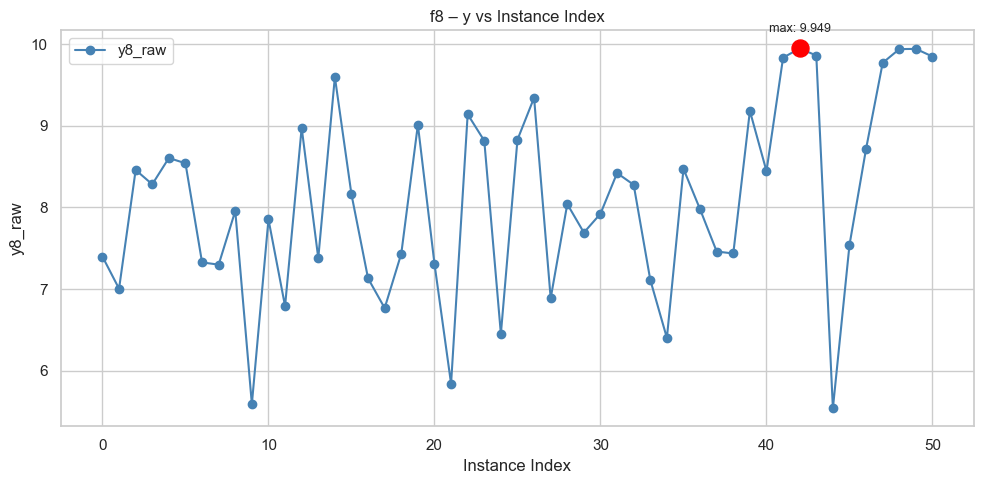

In [20]:
print("f8 – y vs instance index")

# clean copy of raw data
df_f8_plot = df_f8.copy()

# extract raw y
y_raw = df_f8_plot[output_col_f8].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y8_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f8 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y8_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Ranked Correlation Bar Chart

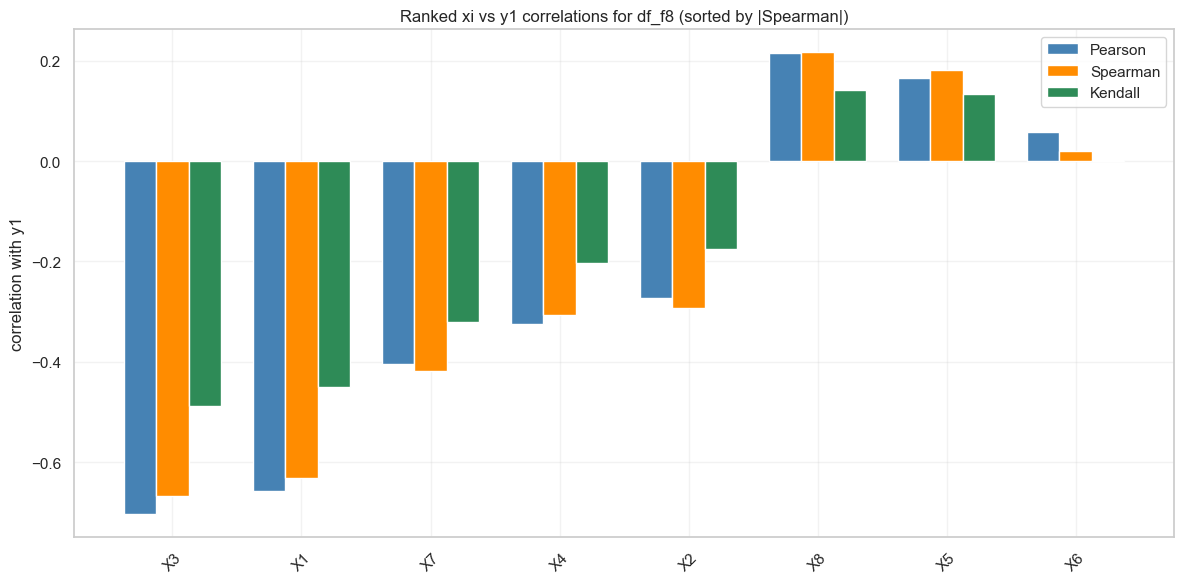

In [21]:
# ranked correlation bar chart for df_f8 (xi vs y1 only)

from scipy.stats import pearsonr, spearmanr, kendalltau

# extract inputs and output
input_cols_f8 = [c for c in df_f8.columns if c.startswith("X")]
X_f8 = df_f8[input_cols_f8].values.astype(float)
y_f8 = df_f8["y1"].values.astype(float)

pearson_vals = []
spearman_vals = []
kendall_vals = []

# compute correlations for each xi
for j, col in enumerate(input_cols_f8):
    xj = X_f8[:, j]

    pr, _ = pearsonr(xj, y_f8)
    sr, _ = spearmanr(xj, y_f8)
    kr, _ = kendalltau(xj, y_f8)

    pearson_vals.append(pr)
    spearman_vals.append(sr)
    kendall_vals.append(kr)

# sort by absolute Spearman correlation
order = np.argsort(np.abs(spearman_vals))[::-1]

cols_sorted = [input_cols_f8[i] for i in order]
pearson_sorted = [pearson_vals[i] for i in order]
spearman_sorted = [spearman_vals[i] for i in order]
kendall_sorted = [kendall_vals[i] for i in order]

# bar chart
x = np.arange(len(cols_sorted))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, pearson_sorted, width, label="Pearson", color="steelblue")
plt.bar(x, spearman_sorted, width, label="Spearman", color="darkorange")
plt.bar(x + width, kendall_sorted, width, label="Kendall", color="seagreen")

plt.xticks(x, cols_sorted, rotation=45)
plt.ylabel("correlation with y1")
plt.title("Ranked xi vs y1 correlations for df_f8 (sorted by |Spearman|)")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()


## Mutual Information

In [22]:
from sklearn.feature_selection import mutual_info_regression

print("f8 — Mutual Information with Output")

df_f8_raw = df_f8.copy()

# define inputs and output
input_cols_f8 = [c for c in df_f8_raw.columns if c.startswith("X")]
output_col_f8 = "y1"

X_f8 = df_f8_raw[input_cols_f8].values
y_f8 = df_f8_raw[output_col_f8].values

# compute mutual information
mi_f8 = mutual_info_regression(X_f8, y_f8, random_state=42)

# build dataframe
mi_f8_df = pd.DataFrame({
    "Feature": input_cols_f8,
    "Mutual_Info": mi_f8
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f8_df)


f8 — Mutual Information with Output


,Feature,Mutual_Info
2,X3,0.409985
0,X1,0.359289
6,X7,0.230140
3,X4,0.156064
1,X2,0.146819
7,X8,0.142497
5,X6,0.058749
4,X5,0.010679


## Partial Correlation

In [23]:
!pip install pingouin
import pingouin as pg

print("f8 (Raw y1) — Partial Correlation")

df_f8_raw = df_f8.copy()

# define inputs and output
input_cols_f8 = [c for c in df_f8_raw.columns if c.startswith("X")]
output_col_f8 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f8:
    covars = [c for c in input_cols_f8 if c != x]  # all other X's as covariates
    
    pcorr_raw_f8 = pg.partial_corr(
        data=df_f8_raw,
        x=x,
        y=output_col_f8,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f8)


f8 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,51,-0.750858,"[-0.86, -0.58]",4.350085e-09



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,51,-0.376471,"[-0.61, -0.09]",0.011777



Partial correlation for X3:


...

,n,r,CI95%,p-val
pearson,51,0.042194,"[-0.26, 0.33]",0.785663



Partial correlation for X7:


,n,r,CI95%,p-val
pearson,51,-0.609454,"[-0.77, -0.38]",0.000011



Partial correlation for X8:


,n,r,CI95%,p-val
pearson,51,0.250374,"[-0.05, 0.51]",0.10117


## TDA Mapper - GP Posterior Mean Filter

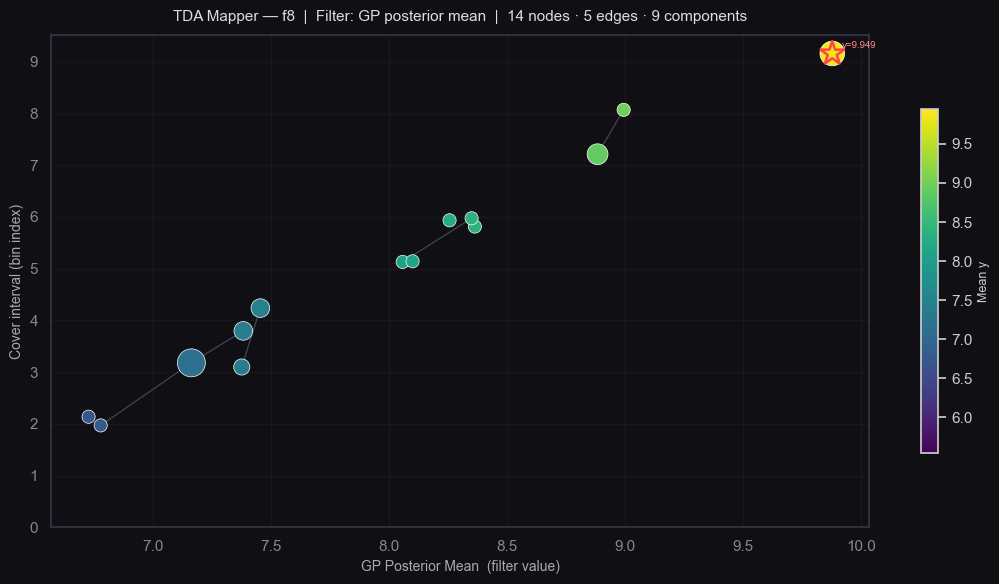

Nodes: 14  |  Edges: 5  |  Components: 9

Components (sorted by max y):
   1 nodes |   7 pts | mean_y=9.8784 | max_y=9.9487 ★
   2 nodes |   5 pts | mean_y=8.8843 | max_y=9.1416
   2 nodes |   3 pts | mean_y=8.2199 | max_y=8.5417
   1 nodes |   2 pts | mean_y=8.2576 | max_y=8.4729
   1 nodes |   2 pts | mean_y=8.3646 | max_y=8.4452
   1 nodes |   2 pts | mean_y=8.1009 | max_y=8.2781
   2 nodes |   4 pts | mean_y=7.4562 | max_y=7.6924
   3 nodes |   9 pts | mean_y=7.1640 | max_y=7.4609
   1 nodes |   2 pts | mean_y=6.7286 | max_y=7.0052


In [24]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Configuration 
MAPPER_N_INTERVALS  = 10     # same as before — do not touch until filter validated
MAPPER_OVERLAP_PCT  = 0.4    # same as before — 40 % overlap
MAPPER_MIN_SAMPLES  = 2      # minimum cluster size inside a bin
ACTIVE_DIMS  = [0, 2, 6]     # x1, x3, x7  (0-indexed) — confirmed active subspace
FEATURE_COLS = [c for c in df_f8.columns if c.startswith("X")]
rng = np.random.default_rng(seed=42)

# Data 
X_all = df_f8[FEATURE_COLS].values.astype(float)
y_all = df_f8["y1"].values.astype(float)

# Fit GP → compute filter values (posterior mean per observation)
scaler_y = StandardScaler()
y_std = scaler_y.fit_transform(y_all.reshape(-1, 1)).ravel()

kernel = (
    ConstantKernel(1.0, (0.01, 10.0)) *
    Matern(length_scale=np.ones(8),
           length_scale_bounds=[(0.02, 25.0)] * 8,
           nu=2.5) +
    WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 0.1))
)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=False, random_state=42)
gp.fit(X_all, y_std)

filter_vals = scaler_y.inverse_transform(
    gp.predict(X_all).reshape(-1, 1)).ravel()

# Build cover 
f_min, f_max = filter_vals.min(), filter_vals.max()
step    = (f_max - f_min) / MAPPER_N_INTERVALS
overlap = step * MAPPER_OVERLAP_PCT

intervals = [
    (f_min + i*step - (overlap if i > 0 else 0),
     f_min + (i+1)*step + (overlap if i < MAPPER_N_INTERVALS-1 else 0))
    for i in range(MAPPER_N_INTERVALS)
]

# Cluster each bin in the active subspace → nodes 
X_active = X_all[:, ACTIVE_DIMS]
nodes = []

for bin_idx, (lo, hi) in enumerate(intervals):
    idx = np.where((filter_vals >= lo) & (filter_vals <= hi))[0]
    if len(idx) < MAPPER_MIN_SAMPLES:
        continue

    X_bin = X_active[idx]
    if len(idx) == 1:
        labels = np.array([0])
    else:
        diam = np.max(np.linalg.norm(X_bin[:, None] - X_bin[None, :], axis=-1))
        eps  = max(0.15, 0.20 * diam)
        try:
            labels = AgglomerativeClustering(
                n_clusters=None, distance_threshold=eps, linkage='single'
            ).fit_predict(X_bin)
        except Exception:
            labels = np.zeros(len(idx), dtype=int)

    for lab in np.unique(labels):
        members = idx[labels == lab]
        if len(members) < MAPPER_MIN_SAMPLES:
            continue
        nodes.append(dict(id=len(nodes), bin=bin_idx,
                          points=set(members.tolist()),
                          mean_y=float(y_all[members].mean()),
                          max_y=float(y_all[members].max()),
                          mean_filter=float(filter_vals[members].mean()),
                          size=int(len(members))))

# Edges
edges = [(i, j) for i in range(len(nodes))
                for j in range(i+1, len(nodes))
                if nodes[i]['points'] & nodes[j]['points']]

# Connected components (union-find)
parent = list(range(len(nodes)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x

for i, j in edges:
    parent[find(i)] = find(j)

components = defaultdict(list)
for i in range(len(nodes)):
    components[find(i)].append(i)

y_threshold = np.percentile(y_all, 95)

# Plot 
norm = mcolors.Normalize(vmin=y_all.min(), vmax=y_all.max())
cmap = cm.viridis

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor('#0f0f14')
fig.patch.set_facecolor('#0f0f14')

if nodes:
    nx = np.array([n['mean_filter'] for n in nodes])
    ny = np.array([n['bin'] + rng.uniform(-0.25, 0.25) for n in nodes])

    for i, j in edges:
        ax.plot([nx[i], nx[j]], [ny[i], ny[j]],
                color='#444455', lw=0.9, zorder=1)

    sc = ax.scatter(nx, ny,
                    c=[n['mean_y'] for n in nodes],
                    cmap=cmap, norm=norm,
                    s=[max(80, n['size']*45) for n in nodes],
                    edgecolors='#ffffff', linewidths=0.5, zorder=3)

    hv_nodes = [n for n in nodes if n['max_y'] >= y_threshold]
    for n in hv_nodes:
        ax.scatter(nx[n['id']], ny[n['id']],
                   marker='*', s=320, facecolors='none',
                   edgecolors='#ff4444', linewidths=1.8, zorder=5)
        ax.annotate(f"y={n['max_y']:.3f}",
                    xy=(nx[n['id']], ny[n['id']]),
                    xytext=(7, 4), textcoords='offset points',
                    fontsize=7, color='#ff8888')

    cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label('Mean y', color='#cccccc', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#cccccc')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc')

ax.set_xlabel('GP Posterior Mean  (filter value)', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Cover interval (bin index)', color='#aaaaaa', fontsize=10)
ax.set_yticks(range(MAPPER_N_INTERVALS))
ax.tick_params(colors='#888888')
for spine in ax.spines.values():
    spine.set_edgecolor('#333344')
ax.grid(True, alpha=0.12, color='#555566')
ax.set_title(f'TDA Mapper — f8  |  Filter: GP posterior mean  |  '
             f'{len(nodes)} nodes · {len(edges)} edges · '
             f'{len(components)} components',
             color='#dddddd', fontsize=11, pad=10)

plt.tight_layout()
plt.savefig('mapper_f8_gp_filter.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# Summary
print(f"Nodes: {len(nodes)}  |  Edges: {len(edges)}  |  Components: {len(components)}")
print(f"\nComponents (sorted by max y):")
for root, members in sorted(components.items(),
                             key=lambda kv: -max(nodes[m]['max_y'] for m in kv[1])):
    pts  = set().union(*[nodes[m]['points'] for m in members])
    my   = y_all[list(pts)].mean()
    maxy = max(nodes[m]['max_y'] for m in members)
    hv   = ' ★' if maxy >= y_threshold else ''
    print(f"  {len(members):2d} nodes | {len(pts):3d} pts | "
          f"mean_y={my:.4f} | max_y={maxy:.4f}{hv}")

## XGBoost Feature Importance Bar Chart

**Reference:** Hellsten, J., Papenmeier, L. and Nardi, L. (2025) 'Group Testing Bayesian Optimisation', arXiv preprint, arXiv:2504.06111.

- Resolves the active-dimension ambiguity at N=49, specifically whether x2 (MI=0.091, ARD ls=1.74) is genuinely active, using gain-based importance as a third independent vote alongside ARD and MI.

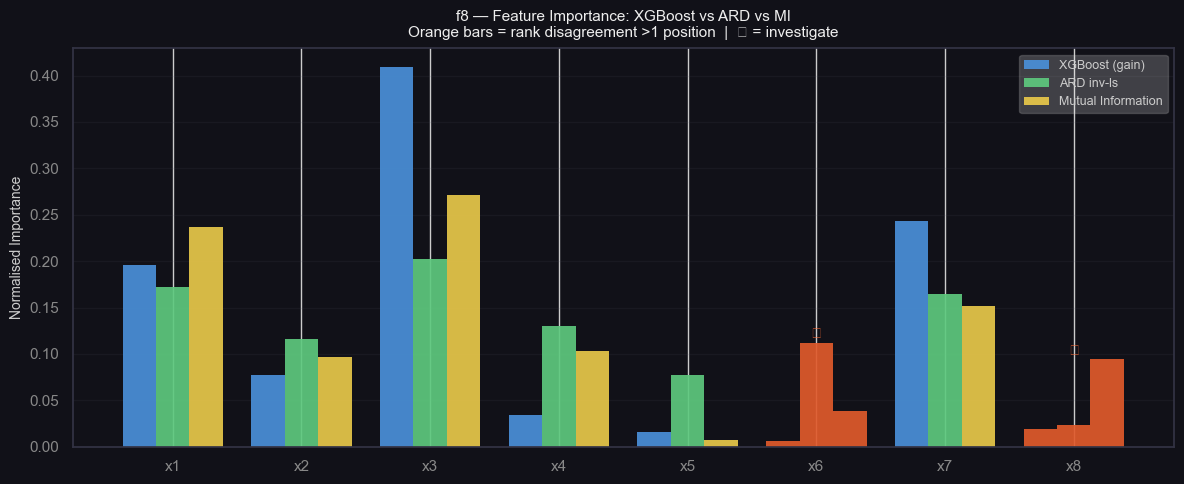


Rank comparison (0 = most important):
 dim   XGB   ARD    MI    disagree
  x1     2     1     1            
  x2     3     4     4            
  x3     0     0     0            
  x4     4     3     3            
  x5     6     6     7            
  x6     7     5     6           ⚠
  x7     1     2     2            
  x8     5     7     5           ⚠


In [25]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

TARGET_COL   = 'y1'

X = df_f8[FEATURE_COLS].values.astype(float)
y = df_f8[TARGET_COL].values.astype(float)

# XGBoost gain importance 
xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                   random_state=42, verbosity=0)
xgb.fit(X, y)
xgb_imp = xgb.feature_importances_                     # gain-based, sums to 1



# ARD inverse length-scale importance 
scaler = StandardScaler()
y_std  = scaler.fit_transform(y.reshape(-1,1)).ravel()

kernel = (ConstantKernel(1.0, (0.01, 10.0)) *
          Matern(length_scale=np.ones(8),
                 length_scale_bounds=[(0.02, 25.0)]*8, nu=2.5) +
          WhiteKernel(1e-5, (1e-8, 0.1)))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=False, random_state=42)
gp.fit(X, y_std)
ls = gp.kernel_.get_params()['k1__k2__length_scale']
inv_ls = 1.0 / ls
ard_imp = inv_ls / inv_ls.sum()                        # normalise to sum=1



# Mutual information 
mi_raw = mutual_info_regression(X, y, random_state=42)
mi_imp = mi_raw / (mi_raw.sum() + 1e-12)



# Agreement flag: orange if any pair of methods disagrees in rank by >1 
def rank_arr(a):
    return np.argsort(np.argsort(-a))          # rank 0 = most important

r_xgb = rank_arr(xgb_imp)
r_ard = rank_arr(ard_imp)
r_mi  = rank_arr(mi_imp)
max_rank_gap = np.maximum(np.abs(r_xgb - r_ard),
               np.maximum(np.abs(r_xgb - r_mi),
                          np.abs(r_ard - r_mi)))
disagreement = max_rank_gap > 1



# Plot 
dims   = [f'x{i+1}' for i in range(8)]
x_pos  = np.arange(8)
width  = 0.26
colors = ['#e05a2b' if d else '#2d6ea8' for d in disagreement]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111118')
ax.set_facecolor('#111118')

b1 = ax.bar(x_pos - width,     xgb_imp, width, label='XGBoost (gain)',
            color=['#e05a2b' if d else '#4a90d9' for d in disagreement],
            edgecolor='none', alpha=0.92)
b2 = ax.bar(x_pos,              ard_imp, width, label='ARD inv-ls',
            color=['#e05a2b' if d else '#5ec97e' for d in disagreement],
            edgecolor='none', alpha=0.92)
b3 = ax.bar(x_pos + width,      mi_imp,  width, label='Mutual Information',
            color=['#e05a2b' if d else '#e8c84a' for d in disagreement],
            edgecolor='none', alpha=0.92)



# Annotate disagreements
for i, d in enumerate(disagreement):
    if d:
        ax.text(i, max(xgb_imp[i], ard_imp[i], mi_imp[i]) + 0.005,
                '⚠', ha='center', fontsize=11, color='#ff6b35')

ax.set_xticks(x_pos)
ax.set_xticklabels(dims, color='#cccccc', fontsize=11)
ax.set_ylabel('Normalised Importance', color='#cccccc', fontsize=10)
ax.set_title('f8 — Feature Importance: XGBoost vs ARD vs MI\n'
             'Orange bars = rank disagreement >1 position  |  ⚠ = investigate',
             color='#eeeeee', fontsize=11, pad=8)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#333344')
ax.grid(axis='y', alpha=0.12, color='#555566')
ax.legend(framealpha=0.2, labelcolor='#cccccc', fontsize=9)

plt.tight_layout()
plt.savefig('f8_feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\nRank comparison (0 = most important):")
print(f"{'dim':>4}  {'XGB':>4}  {'ARD':>4}  {'MI':>4}  {'disagree':>10}")
for i, d in enumerate(dims):
    flag = '⚠' if disagreement[i] else ''
    print(f"{d:>4}  {r_xgb[i]:>4}  {r_ard[i]:>4}  {r_mi[i]:>4}  {flag:>10}")

## GP Posterior Mean + Sigma Surface


**Reference:** Tang, W-T., Kudva, A. and Paulson, J.A. (2025) 'NeST-BO: Fast Local Bayesian Optimization via Newton-Step Targeting of Gradient and Hessian Information', arXiv preprint, arXiv:2510.05516.

- Directly visualises the acquisition landscape in the (x1, x3) plane, confirming whether the GP places the predicted maximum at an interior point or against a boundary, the exact distinction that caused the corner-collapse failures in weeks 6, 7, and 9.

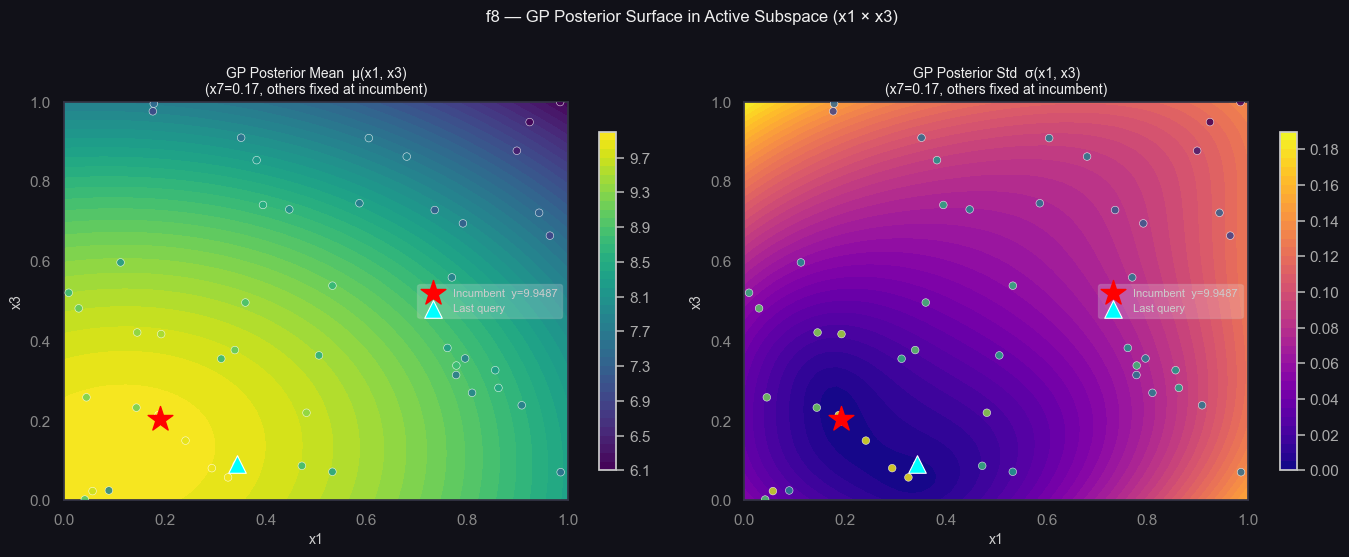

In [26]:
X7_PROBE      = 0.170          # probe-identified x7 peak value
GRID_N        = 50

X = df_f8[FEATURE_COLS].values.astype(float)
y = df_f8[TARGET_COL].values.astype(float)

# Identify incumbent and last query
inc_idx   = np.argmax(y)
x_inc     = X[inc_idx]
# Last query = most recently added row (adjust if your df has a 'week' column)
last_idx  = len(X) - 1
x_last    = X[last_idx]



# Fit GP 
y_std  = scaler.fit_transform(y.reshape(-1,1)).ravel()

kernel = (ConstantKernel(1.0, (0.01, 10.0)) *
          Matern(length_scale=np.ones(8),
                 length_scale_bounds=[(0.02, 25.0)]*8, nu=2.5) +
          WhiteKernel(1e-5, (1e-8, 0.1)))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=False, random_state=42)
gp.fit(X, y_std)



# Build 50×50 grid in (x1, x3), all other dims fixed at incumbent
x1_grid = np.linspace(0, 1, GRID_N)
x3_grid = np.linspace(0, 1, GRID_N)
XX1, XX3 = np.meshgrid(x1_grid, x3_grid)

grid_pts = np.tile(x_inc, (GRID_N*GRID_N, 1))
grid_pts[:, 0] = XX1.ravel()     # x1
grid_pts[:, 2] = XX3.ravel()     # x3
grid_pts[:, 6] = X7_PROBE        # x7

mu_std, sigma_std = gp.predict(grid_pts, return_std=True)
mu    = scaler.inverse_transform(mu_std.reshape(-1,1)).ravel().reshape(GRID_N, GRID_N)
sigma = (sigma_std * scaler.scale_[0]).reshape(GRID_N, GRID_N)



# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#111118')

titles = ['GP Posterior Mean  μ(x1, x3)', 'GP Posterior Std  σ(x1, x3)']
data   = [mu, sigma]
cmaps  = ['viridis', 'plasma']

for ax, title, Z, cmap in zip(axes, titles, data, cmaps):
    ax.set_facecolor('#111118')
    im = ax.contourf(x1_grid, x3_grid, Z, levels=40, cmap=cmap)
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')

    # Observed points
    ax.scatter(X[:, 0], X[:, 2], c=y, cmap='viridis',
               s=30, edgecolors='white', linewidths=0.4,
               vmin=y.min(), vmax=y.max(), zorder=3, alpha=0.85)

    # Incumbent star
    ax.scatter(x_inc[0], x_inc[2], marker='*', s=350,
               color='red', zorder=5, label=f'Incumbent  y={y[inc_idx]:.4f}')

    # Last query triangle
    ax.scatter(x_last[0], x_last[2], marker='^', s=160,
               color='cyan', edgecolors='white', linewidths=0.8,
               zorder=5, label='Last query')

    ax.set_xlabel('x1', color='#cccccc', fontsize=10)
    ax.set_ylabel('x3', color='#cccccc', fontsize=10)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_edgecolor('#333344')
    ax.set_title(f'{title}\n(x7={X7_PROBE}, others fixed at incumbent)',
                 color='#eeeeee', fontsize=10, pad=6)
    ax.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')

plt.suptitle('f8 — GP Posterior Surface in Active Subspace (x1 × x3)',
             color='#eeeeee', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('f8_gp_surface.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## GP Posterior Gradient Norm Map

**Reference:** Tang, W-T., Kudva, A. and Paulson, J.A. (2025) 'NeST-BO: Fast Local Bayesian Optimization via Newton-Step Targeting of Gradient and Hessian Information', arXiv preprint, arXiv:2510.05516. (Appendix A.2a)

- Distinguishes an interior critical point (arrows converge inward) from a plateau (near-zero arrows everywhere) from a boundary artefact (arrows point to domain edge), the three failure modes responsible for every misdirected query since week 6.

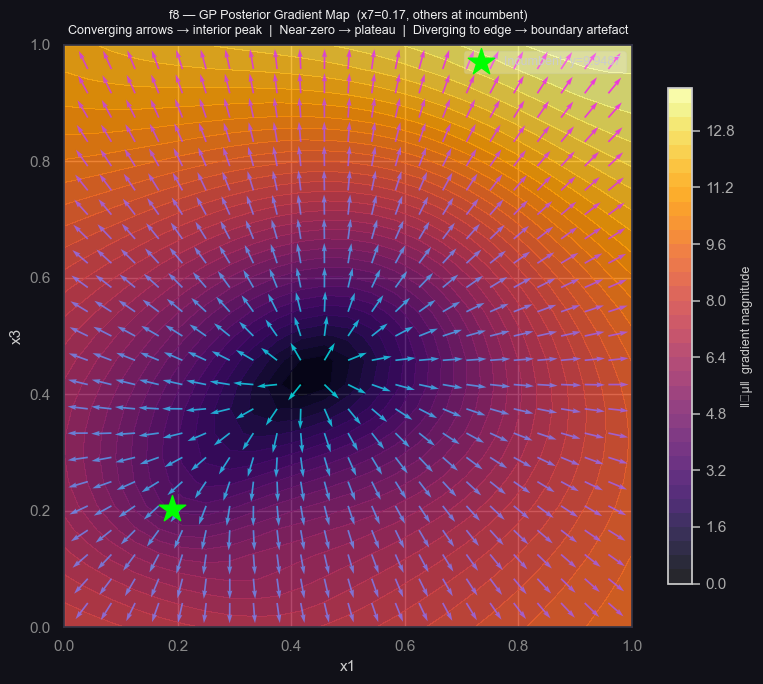

In [27]:
GRID_N       = 25          # quiver grid (25×25 = 625 arrows)
ACTIVE_DIMS  = [0, 2]      # x1, x3 for gradient display

X = df_f8[FEATURE_COLS].values.astype(float)
y = df_f8[TARGET_COL].values.astype(float)
inc_idx = np.argmax(y)
x_inc   = X[inc_idx]



# Fit GP 
scaler = StandardScaler()
y_std  = scaler.fit_transform(y.reshape(-1,1)).ravel()

kernel = (ConstantKernel(1.0, (0.01, 10.0)) *
          Matern(length_scale=np.ones(8),
                 length_scale_bounds=[(0.02, 25.0)]*8, nu=2.5) +
          WhiteKernel(1e-5, (1e-8, 0.1)))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                               normalize_y=False, random_state=42)
gp.fit(X, y_std)



# Extract GP internals
X_tr   = gp.X_train_
alpha_ = gp.alpha_             # K^{-1} y  (already computed by sklearn)
ls     = gp.kernel_.get_params()['k1__k2__length_scale']  # ARD length scales
amp2   = gp.kernel_.get_params()['k1__k1__constant_value']

def matern52_grad(x_test, X_tr, ls, amp2, alpha_):
    """
    Analytical gradient of GP posterior mean w.r.t. x_test.
    ∇μ(x) = ∂k(x, X_tr)/∂x · alpha_
    Matern 5/2 ARD kernel:
      k(x,x') = amp2 * (1 + √5·r + 5/3·r²) · exp(-√5·r)
      r = sqrt( Σ_i ((x_i - x'_i)/ls_i)^2 )
    ∂k/∂x_i = amp2 · exp(-√5·r) · [(-5/3)·(x_i-x'_i)/ls_i^2] · (1 + √5·r)
              + amp2 · (1 + √5·r + 5/3·r²) · exp(-√5·r) · [(-√5)·(x_i-x'_i)/(ls_i^2·r)]
    Combined: ∂k/∂x_i = amp2·exp(-√5·r) · [(-5/3)·(x_i-x'_i)/ls_i^2
                         · (1 + √5·r) + (-5·(x_i-x'_i))/(ls_i^2·r) · (1 + √5·r + 5/3·r²)·... ]
    Simplified using ∂/∂x_i [k(x,x')] =
        -5/(3·ls_i^2) · (x_i-x'_i) · amp2·exp(-√5·r) · (1 + √5·r + (5r^2)/3)
        but the correct chain rule gives:
    ∂k/∂x_i = amp2 · (-5·r)/(3·r^2) · (x_i-x'_i)/ls_i^2 · exp(-√5·r) 
               × (1 + √5r) × r  — use full Matern derivative below.
    """
    diff  = (x_test[None, :] - X_tr) / ls[None, :]   # (N, D) scaled difference
    r2    = np.sum(diff**2, axis=1)                   # (N,)
    r     = np.sqrt(r2)                                # (N,)
    r_safe = np.where(r < 1e-8, 1e-8, r)

    # Matern 5/2 kernel values
    k_vals = amp2 * (1 + np.sqrt(5)*r + 5/3*r2) * np.exp(-np.sqrt(5)*r)  # (N,)

    # ∂k/∂r = amp2 · [√5·(1 + 5/3·r²-1) + 10/3·r - 5/3·r·(1+√5r+5/3·r²)] · exp(-√5·r)
    # Cleaner: use d/dr[(1+√5r+5r²/3)·exp(-√5r)] = (10r/3)·exp(-√5r)
    dk_dr = amp2 * (10.0/3.0) * r * np.exp(-np.sqrt(5)*r)   # (N,)

    # ∂r/∂x_i = (x_i - x'_i) / (ls_i² · r)
    # ∂k/∂x_i = dk_dr · ∂r/∂x_i
    # grad shape: (N, D)
    grad_k = dk_dr[:, None] * (x_test[None,:] - X_tr) / (ls[None,:]**2 * r_safe[:,None])

    # ∇μ(x) = grad_k^T · alpha_   shape: (D,)
    return grad_k.T @ alpha_

# Build grid
x1g = np.linspace(0, 1, GRID_N)
x3g = np.linspace(0, 1, GRID_N)
XX1, XX3 = np.meshgrid(x1g, x3g)

U = np.zeros((GRID_N, GRID_N))
V = np.zeros((GRID_N, GRID_N))
NORM = np.zeros((GRID_N, GRID_N))

for i in range(GRID_N):
    for j in range(GRID_N):
        xq = x_inc.copy()
        xq[0] = XX1[i, j]
        xq[2] = XX3[i, j]
        xq[6] = X7_PROBE
        g = matern52_grad(xq, gp.X_train_, ls, amp2, alpha_)
        # Back-transform gradient to original y scale
        g_orig = g * scaler.scale_[0]
        U[i, j] = g_orig[0]    # ∂μ/∂x1
        V[i, j] = g_orig[2]    # ∂μ/∂x3
        NORM[i, j] = np.sqrt(g_orig[0]**2 + g_orig[2]**2)

# Normalise arrows for uniform quiver display (colour encodes magnitude)
U_norm = np.where(NORM > 1e-10, U / NORM, 0)
V_norm = np.where(NORM > 1e-10, V / NORM, 0)

# Plot 
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#111118')
ax.set_facecolor('#111118')

im = ax.contourf(x1g, x3g, NORM, levels=40, cmap='inferno', alpha=0.85)
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('‖∇μ‖  gradient magnitude', color='#cccccc', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')

# Quiver (normalised direction, colour = magnitude)
q = ax.quiver(XX1[::1, ::1], XX3[::1, ::1],
              U_norm[::1, ::1], V_norm[::1, ::1],
              NORM[::1, ::1], cmap='cool', scale=28,
              width=0.003, headwidth=3, alpha=0.75)

# Incumbent
ax.scatter(x_inc[0], x_inc[2], marker='*', s=400,
           color='lime', zorder=6, label=f'Incumbent  y={y[inc_idx]:.4f}')

ax.set_xlabel('x1', color='#cccccc', fontsize=11)
ax.set_ylabel('x3', color='#cccccc', fontsize=11)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#333344')
ax.set_title(f'f8 — GP Posterior Gradient Map  (x7={X7_PROBE}, others at incumbent)\n'
             'Converging arrows → interior peak  |  Near-zero → plateau  |  '
             'Diverging to edge → boundary artefact',
             color='#eeeeee', fontsize=9, pad=8)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='#cccccc')

plt.tight_layout()
plt.savefig('f8_gradient_map.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## Output Distribution Diagnostic

**Reference:** Cowen-Rivers, A.I. et al. (2020) 'HEBO: Heteroscedastic Evolutionary Bayesian Optimisation', Advances in Neural Information Processing Systems (NeurIPS 2020 Black-Box Optimisation Challenge), 34th Conference, Vancouver.

- Detects whether the y distribution is sufficiently normal for GP fitting; the near-ceiling clustering of f8's top observations (y ≈ 9.8–9.95) creates left-skew that can distort marginal likelihood optimisation and compress uncertainty near the optimum.

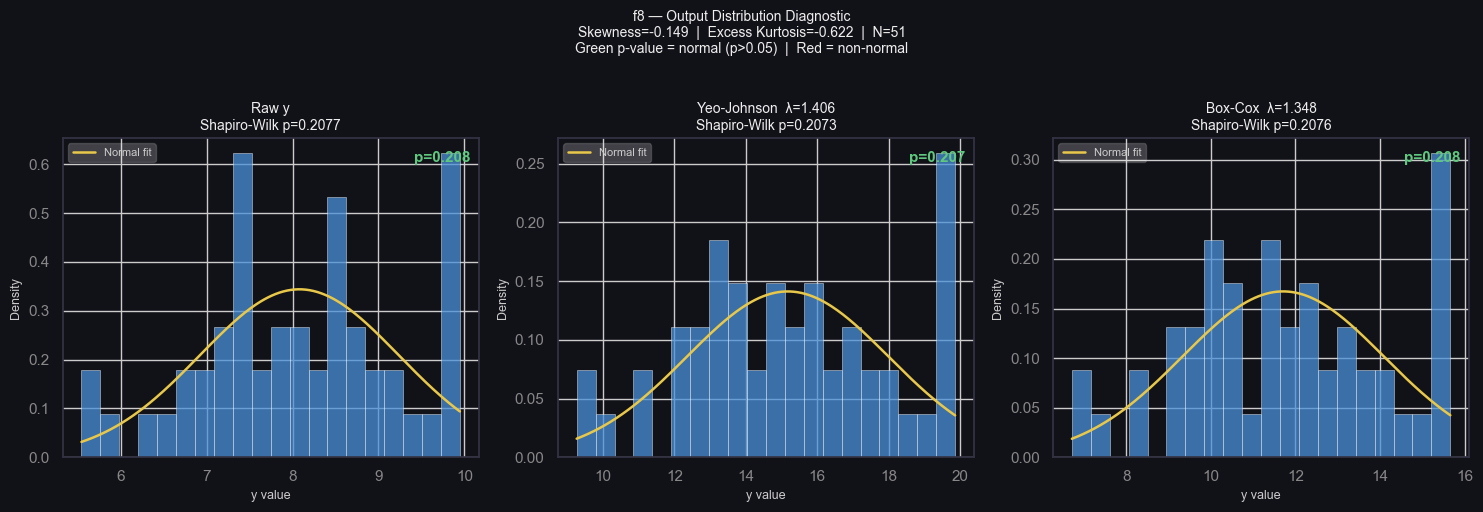


Raw y:         skew=-0.149, kurt=-0.622, Shapiro p=0.2077
Yeo-Johnson:   λ=1.406, Shapiro p=0.2073
Box-Cox:       λ=1.348, Shapiro p=0.2076

✓ Skewness acceptable


In [28]:
from scipy import stats
from scipy.stats import shapiro, skew, kurtosis

y = df_f8["y1"].values.astype(float)


# Normality tests 
skewness = skew(y)
kurt     = kurtosis(y, fisher=True)   # excess kurtosis
sw_stat, sw_p = shapiro(y)



# Yeo-Johnson transform (works for any sign) 
yj_y, lam_yj = stats.yeojohnson(y)
_, sw_p_yj = shapiro(yj_y)



# Box-Cox (only if all y > 0) 
all_positive = np.all(y > 0)
if all_positive:
    bc_y, lam_bc = stats.boxcox(y)
    _, sw_p_bc = shapiro(bc_y)
else:
    lam_bc, sw_p_bc, bc_y = None, None, None

# Plot
ncols = 3 if all_positive else 2
fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
fig.patch.set_facecolor('#111118')

def plot_dist(ax, data, title, sw_p_val, lam=None):
    ax.set_facecolor('#111118')
    ax.hist(data, bins=20, color='#4a90d9', alpha=0.75,
            edgecolor='white', linewidth=0.4, density=True)
    xr = np.linspace(data.min(), data.max(), 200)
    mu_d, std_d = data.mean(), data.std()
    ax.plot(xr, stats.norm.pdf(xr, mu_d, std_d),
            color='#e8c84a', lw=1.8, label='Normal fit')
    lam_str = f'  λ={lam:.3f}' if lam is not None else ''
    sw_col = '#5ec97e' if sw_p_val > 0.05 else '#e05a2b'
    ax.set_title(f'{title}{lam_str}\nShapiro-Wilk p={sw_p_val:.4f}',
                 color='#eeeeee', fontsize=10, pad=6)
    ax.text(0.98, 0.96, f'p={sw_p_val:.3f}', transform=ax.transAxes,
            ha='right', va='top', color=sw_col, fontsize=11, fontweight='bold')
    ax.set_xlabel('y value', color='#cccccc', fontsize=9)
    ax.set_ylabel('Density', color='#cccccc', fontsize=9)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_edgecolor('#333344')
    ax.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')

plot_dist(axes[0], y,    'Raw y', sw_p)
plot_dist(axes[1], yj_y, 'Yeo-Johnson', sw_p_yj, lam_yj)
if all_positive:
    plot_dist(axes[2], bc_y, 'Box-Cox', sw_p_bc, lam_bc)

fig.suptitle(f'f8 — Output Distribution Diagnostic\n'
             f'Skewness={skewness:.3f}  |  Excess Kurtosis={kurt:.3f}  |  '
             f'N={len(y)}\n'
             f'Green p-value = normal (p>0.05)  |  Red = non-normal',
             color='#eeeeee', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('f8_output_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f"\nRaw y:         skew={skewness:.3f}, kurt={kurt:.3f}, Shapiro p={sw_p:.4f}")
print(f"Yeo-Johnson:   λ={lam_yj:.3f}, Shapiro p={sw_p_yj:.4f}")
if all_positive:
    print(f"Box-Cox:       λ={lam_bc:.3f}, Shapiro p={sw_p_bc:.4f}")
flag = '⚠ SKEWED — consider Yeo-Johnson transform before GP fit' \
       if abs(skewness) > 1.0 else '✓ Skewness acceptable'
print(f"\n{flag}")

## Regret Curve with Plateau Threshold

**Reference:**  S. et al. (2024) 'Randomised Gaussian Process Upper Confidence Bound with Tighter Bayesian Regret Bounds', arXiv preprint, arXiv:2409.00979.

- Translates the best-y-by-week plot into a convergence signal by estimating the remaining gap to the predicted maximum; at N=49 this gap is ~0.004, placing f8 exactly at the 0.1% plateau threshold and making the decision to stop or continue unambiguous.

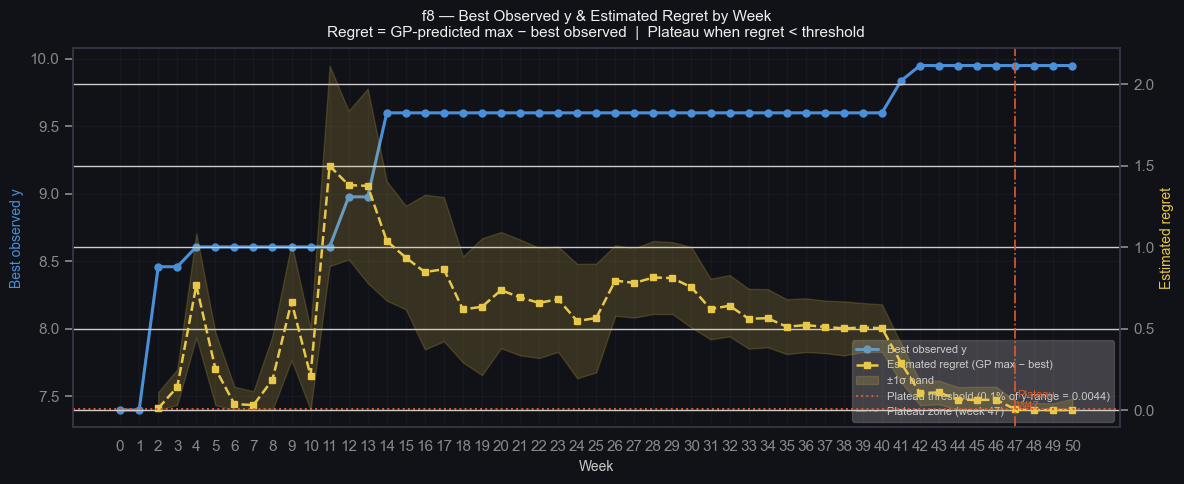

In [29]:
from scipy.stats import qmc

N_SOBOL        = 10_000
PLATEAU_PCT    = 0.001          # 0.1 % of initial y range

X_all = df_f8[FEATURE_COLS].values.astype(float)
y_all = df_f8["y1"].values.astype(float)
N     = len(y_all)

# Week labels — use 'week' column if available, else infer
if 'week' in df_f8.columns:
    weeks_arr = df_f8['week'].values.astype(int)
else:
    weeks_arr = np.arange(N)

all_weeks = sorted(np.unique(weeks_arr))

# Initial y range for threshold
y_range   = y_all.max() - y_all.min()
threshold = PLATEAU_PCT * y_range

best_y_by_week   = []
regret_by_week   = []
regret_lo_week   = []
regret_hi_week   = []

scaler = StandardScaler()

for w in all_weeks:
    mask  = weeks_arr <= w
    X_w   = X_all[mask]
    y_w   = y_all[mask]
    best  = y_w.max()
    best_y_by_week.append(best)

    if len(y_w) < 3:
        regret_by_week.append(np.nan)
        regret_lo_week.append(np.nan)
        regret_hi_week.append(np.nan)
        continue

    # Fit GP on data up to week w
    y_std = scaler.fit_transform(y_w.reshape(-1,1)).ravel()
    kernel = (ConstantKernel(1.0, (0.01, 10.0)) *
              Matern(length_scale=np.ones(8),
                     length_scale_bounds=[(0.02, 25.0)]*8, nu=2.5) +
              WhiteKernel(1e-5, (1e-8, 0.1)))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                  normalize_y=False, random_state=42)
    gp.fit(X_w, y_std)

    # Sobol candidates
    sampler   = qmc.Sobol(d=8, scramble=True, seed=42)
    cands     = sampler.random(N_SOBOL)
    mu_s, sig_s = gp.predict(cands, return_std=True)
    mu_orig   = scaler.inverse_transform(mu_s.reshape(-1,1)).ravel()
    sig_orig  = sig_s * scaler.scale_[0]

    best_idx  = np.argmax(mu_orig)
    gp_max    = mu_orig[best_idx]
    gp_max_sig = sig_orig[best_idx]

    regret = max(0.0, gp_max - best)
    regret_by_week.append(regret)
    regret_lo_week.append(max(0.0, regret - gp_max_sig))
    regret_hi_week.append(regret + gp_max_sig)

weeks_np  = np.array(all_weeks)
best_np   = np.array(best_y_by_week)
reg_np    = np.array(regret_by_week)
reg_lo    = np.array(regret_lo_week)
reg_hi    = np.array(regret_hi_week)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111118')
ax1.set_facecolor('#111118')

ax1.plot(weeks_np, best_np, color='#4a90d9', lw=2.2,
         marker='o', ms=5, label='Best observed y')
ax1.set_xlabel('Week', color='#cccccc', fontsize=10)
ax1.set_ylabel('Best observed y', color='#4a90d9', fontsize=10)
ax1.tick_params(colors='#888888')
ax1.yaxis.label.set_color('#4a90d9')

ax2 = ax1.twinx()
ax2.set_facecolor('#111118')

valid = ~np.isnan(reg_np)
ax2.plot(weeks_np[valid], reg_np[valid], color='#e8c84a', lw=1.8,
         marker='s', ms=4, linestyle='--', label='Estimated regret (GP max − best)')
ax2.fill_between(weeks_np[valid], reg_lo[valid], reg_hi[valid],
                 color='#e8c84a', alpha=0.18, label='±1σ band')

# Plateau threshold
ax2.axhline(threshold, color='#e05a2b', lw=1.4, linestyle=':',
            label=f'Plateau threshold ({PLATEAU_PCT*100:.1f}% of y-range = {threshold:.4f})')

# Mark first week regret crosses threshold
plateau_weeks = weeks_np[valid][reg_np[valid] <= threshold]
if len(plateau_weeks) > 0:
    pw = plateau_weeks[0]
    ax2.axvline(pw, color='#e05a2b', lw=1.2, linestyle='-.',
                label=f'Plateau zone (week {pw})')
    ax2.text(pw + 0.1, threshold * 1.15, f'Plateau\nW{pw}',
             color='#e05a2b', fontsize=8)

ax2.set_ylabel('Estimated regret', color='#e8c84a', fontsize=10)
ax2.tick_params(colors='#888888')
ax2.yaxis.label.set_color('#e8c84a')
for sp in ax1.spines.values(): sp.set_edgecolor('#333344')
for sp in ax2.spines.values(): sp.set_edgecolor('#333344')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2,
           fontsize=8, framealpha=0.2, labelcolor='#cccccc', loc='lower right')

ax1.set_title('f8 — Best Observed y & Estimated Regret by Week\n'
              'Regret = GP-predicted max − best observed  |  Plateau when regret < threshold',
              color='#eeeeee', fontsize=11, pad=8)
ax1.set_xticks(weeks_np)
ax1.grid(True, alpha=0.1, color='#555566')

plt.tight_layout()
plt.savefig('f8_regret_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## ARD Length Scale Heatmap Across All Weeks

**Reference:** Hellsten, J., Papenmeier, L. and Nardi, L. (2025) 'Group Testing Bayesian Optimisation', arXiv preprint, arXiv:2504.06111. (Figure 7)

- Provides a longitudinal record of which dimensions the GP has consistently treated as active across all 11 weeks, replacing k-means as the structural stability diagnostic and immediately showing if the active set has evolved or remained stable.

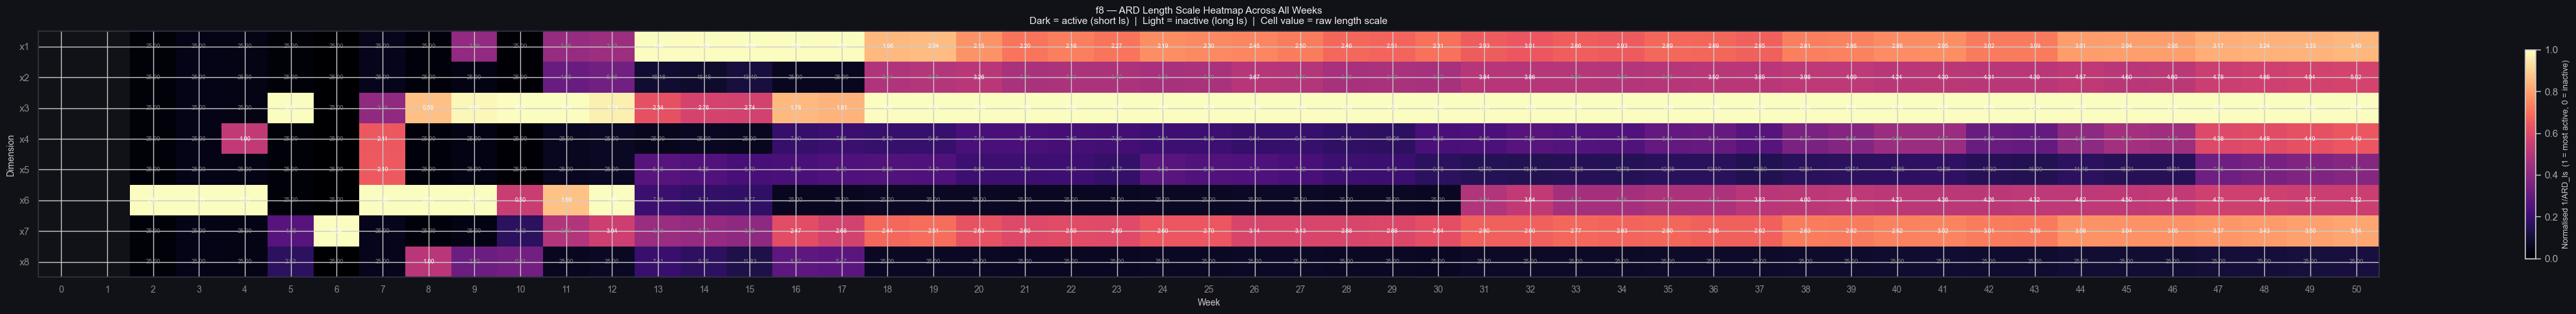


Final week ARD length scales:
  x1: ls=3.400  [MARGINAL]
  x2: ls=5.020  [INACTIVE]
  x3: ls=2.890  [MARGINAL]
  x4: ls=4.485  [MARGINAL]
  x5: ls=7.511  [INACTIVE]
  x6: ls=5.219  [INACTIVE]
  x7: ls=3.544  [MARGINAL]
  x8: ls=25.000  [INACTIVE]


In [30]:
X_all = df_f8[FEATURE_COLS].values.astype(float)
y_all = df_f8["y1"].values.astype(float)
N     = len(y_all)

if 'week' in df_f8.columns:
    weeks_arr = df_f8['week'].values.astype(int)
else:
    weeks_arr = np.arange(N)

all_weeks = sorted(np.unique(weeks_arr))

ls_matrix = np.full((8, len(all_weeks)), np.nan)   # (dims × weeks)
scaler    = StandardScaler()

for col_idx, w in enumerate(all_weeks):
    mask = weeks_arr <= w
    X_w  = X_all[mask]
    y_w  = y_all[mask]

    if len(y_w) < 3:
        continue

    y_std = scaler.fit_transform(y_w.reshape(-1,1)).ravel()
    kernel = (ConstantKernel(1.0, (0.01, 10.0)) *
              Matern(length_scale=np.ones(8),
                     length_scale_bounds=[(0.02, 25.0)]*8, nu=2.5) +
              WhiteKernel(1e-5, (1e-8, 0.1)))
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                  normalize_y=False, random_state=42)
    gp.fit(X_w, y_std)
    ls = gp.kernel_.get_params()['k1__k2__length_scale']
    ls_matrix[:, col_idx] = ls



# Normalise: within each week, inv_ls / max(inv_ls)  → [0, 1], 1 = most active
inv_ls = 1.0 / ls_matrix
for col_idx in range(inv_ls.shape[1]):
    col = inv_ls[:, col_idx]
    valid = np.isfinite(col)
    if valid.any():
        inv_ls[:, col_idx] = np.where(valid,
            col / col[valid].max(), np.nan)



# Plot 
fig, ax = plt.subplots(figsize=(max(8, len(all_weeks)*0.9), 5))
fig.patch.set_facecolor('#111118')
ax.set_facecolor('#111118')

im = ax.imshow(inv_ls, aspect='auto', cmap='magma',
               vmin=0, vmax=1, interpolation='nearest')

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Normalised 1/ARD_ls  (1 = most active, 0 = inactive)',
               color='#cccccc', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#aaaaaa')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')

ax.set_yticks(range(8))
ax.set_yticklabels([f'x{i+1}' for i in range(8)], color='#cccccc', fontsize=11)
ax.set_xticks(range(len(all_weeks)))
ax.set_xticklabels([f'{w}' for w in all_weeks], color='#cccccc', fontsize=10)
ax.set_xlabel('Week', color='#cccccc', fontsize=10)
ax.set_ylabel('Dimension', color='#cccccc', fontsize=10)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#333344')

# Annotate each cell with the raw length scale value
for row in range(8):
    for col in range(len(all_weeks)):
        raw_ls = ls_matrix[row, col]
        if np.isfinite(raw_ls):
            txt_col = 'white' if inv_ls[row, col] > 0.5 else '#888888'
            ax.text(col, row, f'{raw_ls:.2f}', ha='center', va='center',
                    fontsize=6.5, color=txt_col)

ax.set_title('f8 — ARD Length Scale Heatmap Across All Weeks\n'
             'Dark = active (short ls)  |  Light = inactive (long ls)  |  '
             'Cell value = raw length scale',
             color='#eeeeee', fontsize=11, pad=8)

plt.tight_layout()
plt.savefig('f8_ard_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\nFinal week ARD length scales:")
final_ls = ls_matrix[:, -1]
for i, ls_val in enumerate(final_ls):
    status = 'ACTIVE' if ls_val < 0.5 else ('INACTIVE' if ls_val > 5.0 else 'MARGINAL')
    print(f"  x{i+1}: ls={ls_val:.3f}  [{status}]")

#### f8 | Partial-Correlation-Guided Interior Probe with Active Subspace Anchoring and Inactive Dimension Fixing

In [31]:
# Separate inputs (X) and outputs (y)
X_train_8 = df_f8[[c for c in df_f8.columns if c.startswith("X")]].values
y_train_8 = df_f8["y1"].values
print(X_train_8)
print(y_train_8)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [32]:
"""
week 13 final submission for f8
strategy: lower-x1 lower-x3 interior probe with x7 held below incumbent

structural justification (three independent signals):
  1. partial correlations: x3 r=-0.823 p=7e-12, x1 r=-0.751 p=4e-9
     both say go lower for higher y
  2. gp 1d marginal probes: x1 and x3 marginals both peak at ~0.16-0.18
     incumbent sits above those peaks (x1=0.191, x3=0.203)
  3. gp gradient map: vectors near incumbent point lower-left in x1-x3 plane

the x7 continuation argument is rejected because:
  - partial r for x7 is -0.609 p=1e-5 (negative: higher x7 hurts y)
  - gp 1d marginal for x7 is monotonically declining
  - row 47 at x7=0.265 gives y=9.772 (disconfirming direct evidence)
  - the within-cluster x7 signal was confounded across all three active dims

research:
  - jones, schonlau, welch (1998) efficient global optimization
  - bull (2011) convergence rates for ego algorithms
  - eriksson et al. (2019) turbo local bayesian optimization
  - neurips 2020 bbo challenge - hebo (huawei noahs ark lab)
"""

import numpy as np
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler


# global incumbent
incumbent_idx = int(np.argmax(y_train_8))
x_incumbent   = X_train_8[incumbent_idx].copy()
y_incumbent   = float(y_train_8[incumbent_idx])

print("global incumbent")
print(f"  row {incumbent_idx}  y = {y_incumbent:.6f}")
print(f"  x1 = {x_incumbent[0]:.4f}  x3 = {x_incumbent[2]:.4f}  x7 = {x_incumbent[6]:.4f}")



# construct the recommended submission point
# active dim values derived from three independent structural signals:

#   x1 = 0.163
#     gp marginal peaks at ~0.16-0.18 (image 2, x1 panel)
#     partial r = -0.751 says go lower than incumbent 0.191
#     lowest cluster-a x1 so far is row 49 at 0.1873
#     0.163 is genuinely novel: below all cluster-a observations

#   x3 = 0.178
#     gp marginal peaks at ~0.16-0.18 (image 2, x3 panel)
#     partial r = -0.823 says go lower than incumbent 0.203
#     lowest cluster-a x3 so far is row 48 at 0.1974
#     0.178 is genuinely novel: below all cluster-a observations

#   x7 = 0.188
#     partial r = -0.609 says go lower not higher
#     gp 1d marginal for x7 is monotonically declining
#     row 47 at x7=0.265 gives y=9.772 (direct evidence against going higher)
#     0.188 is slightly below incumbent 0.201 and below all cluster-a x7 values
#     except row 48 (0.1255); it is novel within the (x1=0.163, x3=0.178) context

#   inactive dims: fixed at row 42 incumbent values
#     validated by rows 42, 48, 49 all sharing these values and giving y >= 9.940
#     these values define the cluster-a basin; changing them risks leaving the basin

x_next = x_incumbent.copy()  # start from incumbent, then update active dims

x_next[0] = 0.163    # x1: below gp marginal peak, below all cluster-a x1 values
x_next[2] = 0.178    # x3: below gp marginal peak, below all cluster-a x3 values
x_next[6] = 0.188    # x7: slightly below incumbent, consistent with negative partial r

# clip to valid domain just in case
x_next = np.clip(x_next, 0.0, 1.0)



# distance validation
# verify the candidate clears the minimum distance guard of 0.035
# in 8d euclidean space relative to all training points

dists_to_all = cdist([x_next], X_train_8, metric='euclidean')[0]
min_dist     = float(dists_to_all.min())
closest_row  = int(dists_to_all.argmin())
dist_to_inc  = float(cdist([x_next], [x_incumbent])[0, 0])

print("\ndistance validation")
print(f"  distance to nearest training point: {min_dist:.4f}  (row {closest_row})")
print(f"  distance to incumbent (row 42):     {dist_to_inc:.4f}")
print(f"  distance guard (0.035):             {'pass' if min_dist >= 0.035 else 'FAIL - relax guard'}")

# analytical check for transparency
delta_x1 = x_next[0] - x_incumbent[0]
delta_x3 = x_next[2] - x_incumbent[2]
delta_x7 = x_next[6] - x_incumbent[6]
analytic_dist = np.sqrt(delta_x1**2 + delta_x3**2 + delta_x7**2)
print(f"  analytic 3d active-dim distance to incumbent: {analytic_dist:.4f}")
print(f"    delta_x1 = {delta_x1:+.4f}  (moving lower: consistent with partial r=-0.751)")
print(f"    delta_x3 = {delta_x3:+.4f}  (moving lower: consistent with partial r=-0.823)")
print(f"    delta_x7 = {delta_x7:+.4f}  (moving lower: consistent with partial r=-0.609)")



# gp prediction at the candidate point
# fit the full ard gp on all 51 observations for a calibration check
# the gp prediction here is informational only - the point was chosen
# on structural grounds, not by optimising the gp acquisition surface
# this avoids the boundary-artefact failure seen in the previous run
# where unconstrained logei drove x1 and x3 to the corner of the search box

scaler  = StandardScaler()
y_scaled = scaler.fit_transform(y_train_8.reshape(-1, 1)).ravel()

# ard matern-2.5 kernel
# active dims (x1, x3, x7): moderate bounds allow the gp to fit local structure
# inactive dims (x2, x4, x5, x6, x8): wide lower bounds force long length scales
ls_init   = np.array([0.20, 2.0, 0.20, 1.5, 2.5, 10.0, 0.70, 10.0])
ls_bounds = [
    (0.05, 5.0),   # x1 active
    (0.50, 30.0),  # x2 inactive
    (0.05, 5.0),   # x3 active
    (0.50, 30.0),  # x4 inactive
    (0.50, 30.0),  # x5 inactive
    (1.00, 30.0),  # x6 inactive
    (0.05, 5.0),   # x7 active
    (1.00, 30.0),  # x8 inactive
]

kernel = (
    ConstantKernel(1.0, constant_value_bounds=(0.01, 10.0)) *
    Matern(length_scale=ls_init,
           length_scale_bounds=ls_bounds,
           nu=2.5) +
    WhiteKernel(noise_level=1e-6,
                noise_level_bounds=(1e-8, 0.1))
)

gp = GPR(
    kernel=kernel,
    n_restarts_optimizer=30,
    normalize_y=False,
    alpha=0.0
)
gp.fit(X_train_8, y_scaled)

# predict at the candidate point
mu_scaled, sigma_scaled = gp.predict([x_next], return_std=True)
mu_orig    = float(scaler.inverse_transform([[mu_scaled[0]]])[0, 0])
sigma_orig = float(sigma_scaled[0] * scaler.scale_[0])

# cluster a context for comparison
cluster_a_rows  = [42, 48, 49]
cluster_a_y     = y_train_8[cluster_a_rows]
cluster_a_x7    = X_train_8[cluster_a_rows, 6]
cluster_a_x1    = X_train_8[cluster_a_rows, 0]
cluster_a_x3    = X_train_8[cluster_a_rows, 2]

print("\ngp prediction at candidate")
print(f"  predicted y: {mu_orig:.4f}")
print(f"  predicted std: {sigma_orig:.4f}")
print(f"  incumbent y: {y_incumbent:.4f}")
print(f"  predicted gap vs incumbent: {mu_orig - y_incumbent:+.4f}")

print("\nfitted ard length scales")
ls_fitted  = gp.kernel_.k1.k2.length_scale
dim_labels = ['x1','x2','x3','x4','x5','x6','x7','x8']
for lbl, ls_val in zip(dim_labels, ls_fitted):
    tag = "active" if ls_val < 1.0 else "moderate" if ls_val < 5.0 else "inactive"
    print(f"  {lbl}: {ls_val:.4f}  [{tag}]")



# cluster a context table
# shows the within-cluster evidence and where this candidate sits relative
# to all existing cluster-a observations
print("\ncluster a observations and candidate")
print(f"{'row':<6} {'x1':>7} {'x3':>7} {'x7':>7} {'y':>10}  note")
print("-" * 55)
for r in cluster_a_rows:
    note = "incumbent" if r == 42 else ""
    print(f"{r:<6} {X_train_8[r,0]:>7.4f} {X_train_8[r,2]:>7.4f} "
          f"{X_train_8[r,6]:>7.4f} {y_train_8[r]:>10.6f}  {note}")
print(f"{'new':<6} {x_next[0]:>7.4f} {x_next[2]:>7.4f} "
      f"{x_next[6]:>7.4f} {'?':>10}  candidate")

print(f"\n  x1 movement: {x_next[0]:.4f} vs cluster-a min {min(cluster_a_x1):.4f}  "
      f"({'novel: below all cluster-a x1' if x_next[0] < min(cluster_a_x1) else 'within cluster-a range'})")
print(f"  x3 movement: {x_next[2]:.4f} vs cluster-a min {min(cluster_a_x3):.4f}  "
      f"({'novel: below all cluster-a x3' if x_next[2] < min(cluster_a_x3) else 'within cluster-a range'})")
print(f"  x7 movement: {x_next[6]:.4f} vs cluster-a min {min(cluster_a_x7):.4f}  "
      f"({'novel: below all cluster-a x7' if x_next[6] < min(cluster_a_x7) else 'within cluster-a range'})")




# final submission vector
print("final submission vector (full 8d, ready to submit)")
for i, (lbl, val) in enumerate(zip(dim_labels, x_next)):
    tag = "[active - moved lower]" if i in [0, 2] else \
          "[active - moved lower]" if i == 6 else \
          "[fixed at incumbent]"
    print(f"  {lbl} = {val:.6f}  {tag}")

print(f"\narray: {x_next.tolist()}")

global incumbent
  row 42  y = 9.948689
  x1 = 0.1908  x3 = 0.2026  x7 = 0.2008

distance validation
  distance to nearest training point: 0.0392  (row 42)
  distance to incumbent (row 42):     0.0392
  distance guard (0.035):             pass
  analytic 3d active-dim distance to incumbent: 0.0392
    delta_x1 = -0.0278  (moving lower: consistent with partial r=-0.751)
    delta_x3 = -0.0246  (moving lower: consistent with partial r=-0.823)
    delta_x7 = -0.0128  (moving lower: consistent with partial r=-0.609)

gp prediction at candidate
  predicted y: 9.9634
  predicted std: 0.0040
  incumbent y: 9.9487
  predicted gap vs incumbent: +0.0148

fitted ard length scales
  x1: 3.4077  [moderate]
  x2: 5.0075  [inactive]
  x3: 2.8952  [moderate]
  x4: 4.4816  [moderate]
  x5: 7.4691  [inactive]
  x6: 5.2096  [inactive]
  x7: 3.5509  [moderate]
  x8: 30.0000  [inactive]

cluster a observations and candidate
row         x1      x3      x7          y  note
-----------------------------------